In [1]:
from google.colab import files
uploaded = files.upload()

Saving archive.zip to archive.zip


In [2]:
import zipfile

# use the exact filename you just uploaded — check it if this errors
with zipfile.ZipFile('archive.zip', 'r') as zip_ref:
    zip_ref.extractall('/content')

import os
os.listdir()

['.config', 'flipkart_com-ecommerce_sample.csv', 'archive.zip', 'sample_data']

In [3]:
import pandas as pd

df = pd.read_csv('flipkart_com-ecommerce_sample.csv')  # use the exact name from os.listdir()
df.shape

(20002, 15)

In [4]:
df.head()

,uniq_id,crawl_timestamp,product_url,product_name,product_category_tree,pid,retail_price,discounted_price,image,is_FK_Advantage_product,description,product_rating,overall_rating,brand,product_specifications
0,c2d766ca982eca8304150849735ffef9,2016-03-25 22:59:23 +0000,http://www.flipkart.com/alisha-solid-women-s-c...,Alisha Solid Women's Cycling Shorts,"[""Clothing >> Women's Clothing >> Lingerie, Sl...",SRTEH2FF9KEDEFGF,999.0,379.0,"[""http://img5a.flixcart.com/image/short/u/4/a/...",False,Key Features of Alisha Solid Women's Cycling S...,No rating available,No rating available,Alisha,"{""product_specification""=>[{""key""=>""Number of ..."
1,7f7036a6d550aaa89d34c77bd39a5e48,2016-03-25 22:59:23 +0000,http://www.flipkart.com/fabhomedecor-fabric-do...,FabHomeDecor Fabric Double Sofa Bed,"[""Furniture >> Living Room Furniture >> Sofa B...",SBEEH3QGU7MFYJFY,32157.0,22646.0,"[""http://img6a.flixcart.com/image/sofa-bed/j/f...",False,FabHomeDecor Fabric Double Sofa Bed (Finish Co...,No rating available,No rating available,FabHomeDecor,"{""product_specification""=>[{""key""=>""Installati..."
2,f449ec65dcbc041b6ae5e6a32717d01b,2016-03-25 22:59:23 +0000,http://www.flipkart.com/aw-bellies/p/itmeh4grg...,AW Bellies,"[""Footwear >> Women's Footwear >> Ballerinas >...",SHOEH4GRSUBJGZXE,999.0,499.0,"[""http://img5a.flixcart.com/image/shoe/7/z/z/r...",False,Key Features of AW Bellies Sandals Wedges Heel...,No rating available,No rating available,AW,"{""product_specification""=>[{""key""=>""Ideal For""..."
3,0973b37acd0c664e3de26e97e5571454,2016-03-25 22:59:23 +0000,http://www.flipkart.com/alisha-solid-women-s-c...,Alisha Solid Women's Cycling Shorts,"[""Clothing >> Women's Clothing >> Lingerie, Sl...",SRTEH2F6HUZMQ6SJ,699.0,267.0,"[""http://img5a.flixcart.com/image/short/6/2/h/...",False,Key Features of Alisha Solid Women's Cycling S...,No rating available,No rating available,Alisha,"{""product_specification""=>[{""key""=>""Number of ..."
4,bc940ea42ee6bef5ac7cea3fb5cfbee7,2016-03-25 22:59:23 +0000,http://www.flipkart.com/sicons-all-purpose-arn...,Sicons All Purpose Arnica Dog Shampoo,"[""Pet Supplies >> Grooming >> Skin & Coat Care...",PSOEH3ZYDMSYARJ5,220.0,210.0,"[""http://img5a.flixcart.com/image/pet-shampoo/...",False,Specifications of Sicons All Purpose Arnica Do...,No rating available,No rating available,Sicons,"{""product_specification""=>[{""key""=>""Pet Type"",..."


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20002 entries, 0 to 20001
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   uniq_id                  20000 non-null  object 
 1   crawl_timestamp          20000 non-null  object 
 2   product_url              20000 non-null  object 
 3   product_name             20000 non-null  object 
 4   product_category_tree    20000 non-null  object 
 5   pid                      20000 non-null  object 
 6   retail_price             19922 non-null  float64
 7   discounted_price         19922 non-null  float64
 8   image                    19997 non-null  object 
 9   is_FK_Advantage_product  20000 non-null  object 
 10  description              19998 non-null  object 
 11  product_rating           20000 non-null  object 
 12  overall_rating           20000 non-null  object 
 13  brand                    14136 non-null  object 
 14  product_specifications

In [6]:
df.isnull().sum()

,0
uniq_id,2
crawl_timestamp,2
product_url,2
product_name,2
product_category_tree,2
pid,2
retail_price,80
discounted_price,80
image,5
is_FK_Advantage_product,2


In [7]:
df = df.drop(columns=['crawl_timestamp', 'product_url', 'image', 'description',
                       'product_specifications', 'is_FK_Advantage_product', 'pid', 'uniq_id'])
df.shape

(20002, 7)

In [8]:
df = df.dropna(subset=['retail_price', 'discounted_price', 'product_category_tree'])
df.shape

(19922, 7)

In [9]:
df['product_category_tree'].iloc[0]

'["Clothing >> Women\'s Clothing >> Lingerie, Sleep & Swimwear >> Shorts >> Alisha Shorts >> Alisha Solid Women\'s Cycling Shorts"]'

In [10]:
def get_main_category(value):
    value = value.strip('["]')          # remove the [ " ] characters at the edges
    return value.split('>>')[0].strip() # take everything before the first '>>'

df['main_category'] = df['product_category_tree'].apply(get_main_category)
df['main_category'].value_counts().head(15)

,count
main_category,
Clothing,6171
Jewellery,3522
Footwear,1225
Mobiles & Accessories,1097
Automotive,1010
Home Decor & Festive Needs,927
Beauty and Personal Care,709
Home Furnishing,700
Kitchen & Dining,645


In [ ]:
#Clean the data

In [11]:
#Clean the rating columns
df['product_rating'].unique()[:20]

array(['No rating available', '5', '3', '3.6', '3.5', '4.4', '4', '1',
       '2.3', '4.8', '2.7', '4.5', '2.4', '3.2', '4.7', '2', '3.3', '4.3',
       '3.8', '4.2'], dtype=object)

In [12]:
#Create the discount % column
df['discount_pct'] = (df['retail_price'] - df['discounted_price']) / df['retail_price'] * 100
df['discount_pct'].describe()

,discount_pct
count,19922.000000
mean,40.523885
std,23.546676
min,0.000000
25%,21.058178
50%,45.000000
75%,59.971646
max,96.533333


In [13]:
#Clean product rating and overall rating
df['overall_rating'].unique()[:20]

def clean_rating(value):
    if value == 'No rating available':
        return None
    return float(value)

df['product_rating'] = df['product_rating'].apply(clean_rating)
df['overall_rating'] = df['overall_rating'].apply(clean_rating)

df[['product_rating', 'overall_rating']].describe()

,product_rating,overall_rating
count,1839.000000,1839.000000
mean,3.810332,3.810332
std,1.260124,1.260124
min,1.000000,1.000000
25%,3.000000,3.000000
50%,4.000000,4.000000
75%,5.000000,5.000000
max,5.000000,5.000000


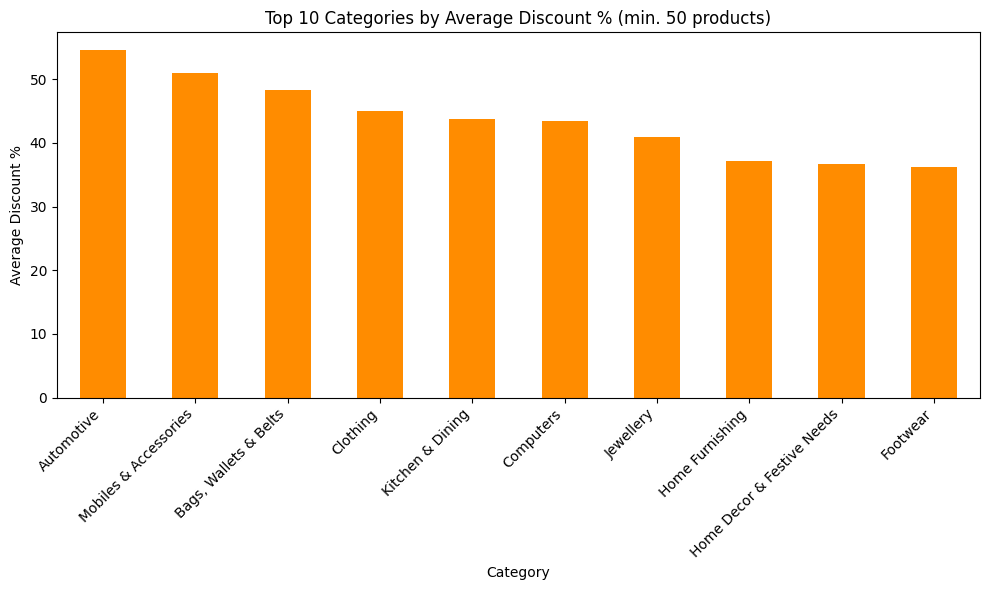

In [17]:
# Question1) Which categories have the highest average discount %?
category_discount_stats = df.groupby('main_category')['discount_pct'].agg(['mean', 'count'])
category_discount_stats = category_discount_stats[category_discount_stats['count'] >= 50]  # only real categories with 50+ products
top_discount_categories = category_discount_stats.sort_values('mean', ascending=False).head(10)

plt.figure(figsize=(10,6))
top_discount_categories['mean'].plot(kind='bar', color='darkorange')
plt.title('Top 10 Categories by Average Discount % (min. 50 products)')
plt.xlabel('Category')
plt.ylabel('Average Discount %')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

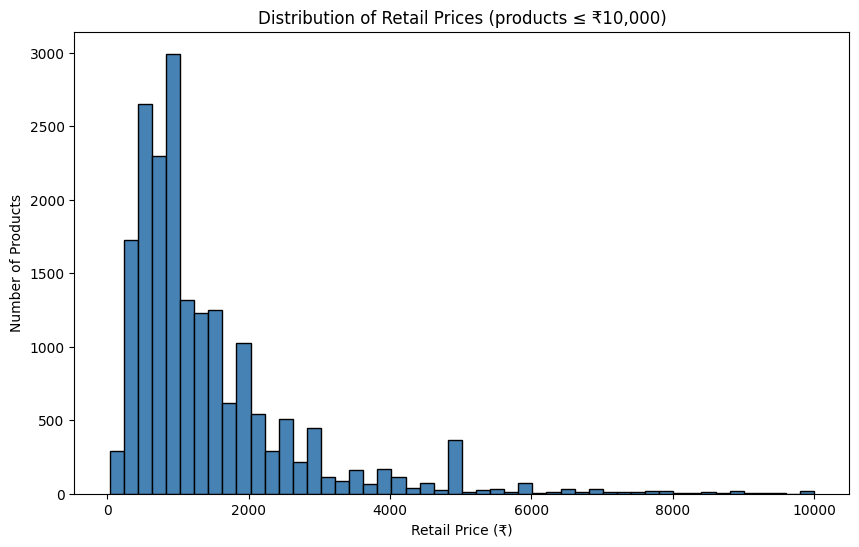

In [18]:
# Question2) Overall price distribution
plt.figure(figsize=(10,6))
df[df['retail_price'] <= 10000]['retail_price'].plot(kind='hist', bins=50, color='steelblue', edgecolor='black')
plt.title('Distribution of Retail Prices (products ≤ ₹10,000)')
plt.xlabel('Retail Price (₹)')
plt.ylabel('Number of Products')
plt.show()

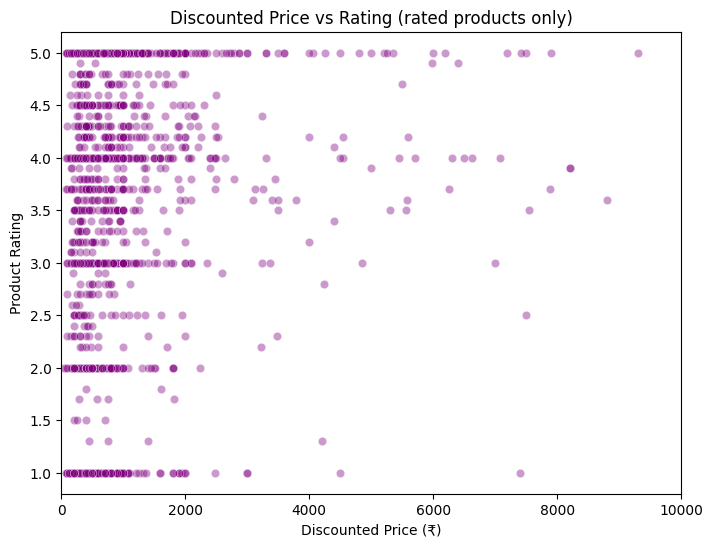

In [21]:
#price vs. rating relationship
import seaborn as sns
rated_products = df[df['product_rating'].notna()]

plt.figure(figsize=(8,6))
sns.scatterplot(x='discounted_price', y='product_rating', data=rated_products, alpha=0.4, color='purple')
plt.title('Discounted Price vs Rating (rated products only)')
plt.xlabel('Discounted Price (₹)')
plt.ylabel('Product Rating')
plt.xlim(0, 10000)
plt.show()


In [22]:
rated_products['discounted_price'].corr(rated_products['product_rating'])

np.float64(0.05734186549882195)

In [23]:
#brand pricing comparison
brand_stats = df.groupby('brand')['retail_price'].agg(['mean', 'count'])
brand_stats = brand_stats[brand_stats['count'] >= 30]  # only brands with 30+ products

print("Top 10 highest-priced brands:")
print(brand_stats.sort_values('mean', ascending=False).head(10))

print("\nTop 10 lowest-priced brands:")
print(brand_stats.sort_values('mean', ascending=True).head(10))

Top 10 highest-priced brands:
                     mean  count
brand                           
Durian       73795.483871     31
Karatcraft   37077.777251    211
BlueStone    36971.010101     99
Radiant Bay  34164.712121    132
Raymond       4889.754717     53
Allure Auto   4215.587607    468
Lal Haveli    3975.757576     33
Lapguard      3674.675676     37
Candy House   2899.000000     30
Enthopia      2895.000000    101

Top 10 lowest-priced brands:
                        mean  count
brand                              
Joyeria Milan     379.000000     35
Junk              386.733333     30
Galz4ever         405.800000     40
Indian Charm      416.675676     37
Clovia            539.000000     36
AdroitZ           542.918919     74
Hi Look           549.666667     33
UpTown            555.823529     34
Jewel Paradise    604.405405     37
First Smart Deal  693.690476     42


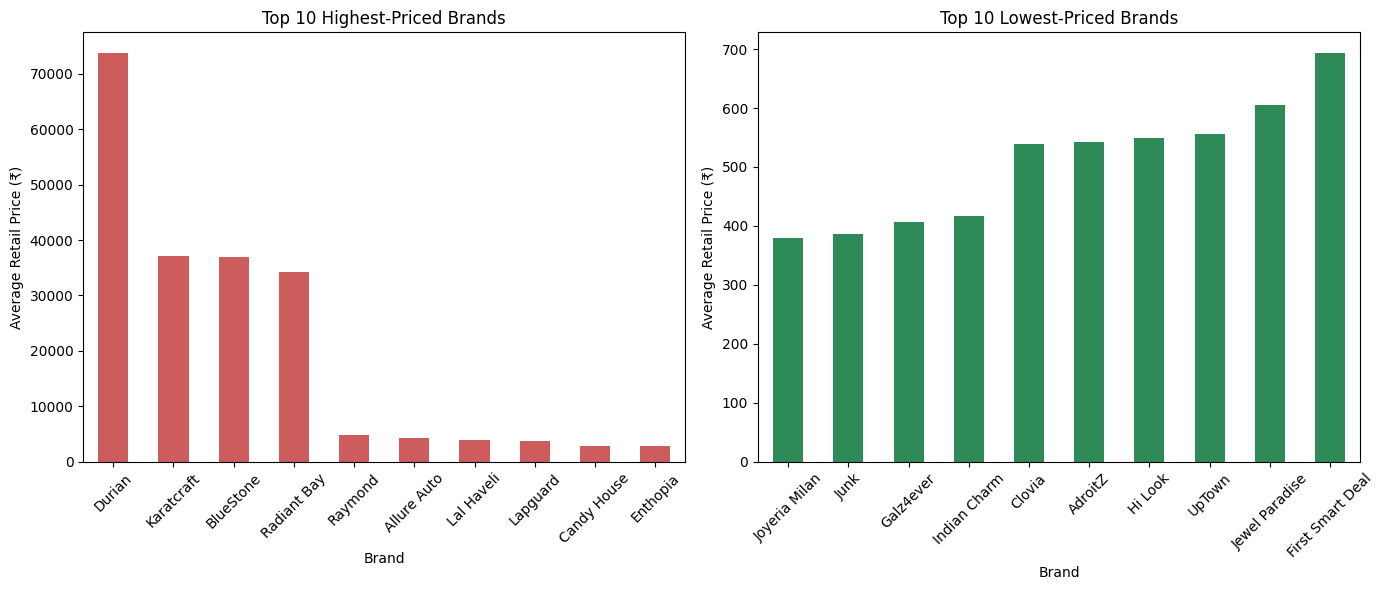

In [24]:
brand_stats = df.groupby('brand')['retail_price'].agg(['mean', 'count'])
brand_stats = brand_stats[brand_stats['count'] >= 30]

top10_highest = brand_stats.sort_values('mean', ascending=False).head(10)
top10_lowest = brand_stats.sort_values('mean', ascending=True).head(10)

fig, axes = plt.subplots(1, 2, figsize=(14,6))

top10_highest['mean'].plot(kind='bar', ax=axes[0], color='indianred')
axes[0].set_title('Top 10 Highest-Priced Brands')
axes[0].set_xlabel('Brand')
axes[0].set_ylabel('Average Retail Price (₹)')
axes[0].tick_params(axis='x', rotation=45)

top10_lowest['mean'].plot(kind='bar', ax=axes[1], color='seagreen')
axes[1].set_title('Top 10 Lowest-Priced Brands')
axes[1].set_xlabel('Brand')
axes[1].set_ylabel('Average Retail Price (₹)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()